# GMM Clustering
ML lab 9  

**Yasir Ahmad**  
**22MIA1064** 

Perform GMM Clustering applying EM algorithm


## Load dataset 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the iris dataset
iris = datasets.load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

## Scaling

In [2]:
X = iris.data

# Standardizing the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

## Gaussian Mixture Models (GMM)  
[comprehensive guide](https://www.kaggle.com/code/marcinrutecki/clustering-methods-comprehensive-study#7.-Gaussian-Mixture-Models-(GMM))  
A Gaussian mixture model (GMM) attempts to find a mixture of multi-dimensional Gaussian probability distributions that best model any input dataset. In the simplest case, GMMs can be used for finding clusters in the same manner as k-means, but because GMM contains a probabilistic model under the hood, it is also possible to find probabilistic cluster assignments.

The Gaussian mixture model uses multiple Gaussian distributions to fit arbitrarily shaped data.

There are several single Gaussian models that act as hidden layers in this hybrid model. So the model calculates the probability that a data point belongs to a specific Gaussian distribution and that's the cluster it will fall under.

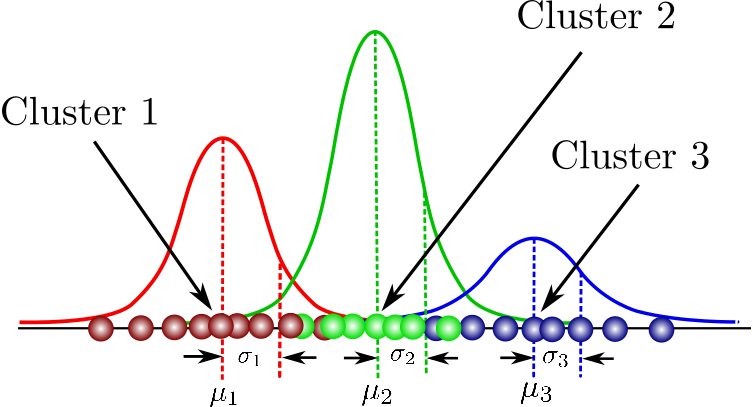

## Advantages and Disadvantages of Gaussian Mixture Models¶
### Advantages of Gaussian Mixture Models (GMM):

* Probabilistic estimates of belonging to each cluster - models provide estimates of the probability that each data point belongs to each cluster. These probability estimates can be very useful when examining ambiguous data points that fall at the border of two clusters.

* Does not assume spherical clusters - model do not assume that all clusters are uniformly shaped spheres. Instead, gaussian mixture models can be used to accommodate clusters of varying shapes.

* Handles clusters of differing sizes gaussian mixture models can also be used to accommodate clusters of varying sizes.

* Less sensitive to scale - that means that you may not need to rescale your variables before using them for clustering.

* Accommodates mixed membership - in kmeans, a point belongs to one and only one cluster, whereas in GMM a point belongs to each cluster to a different degree. The degree is based on the probability of the point being generated from each cluster’s (multivariate) normal distribution, with cluster center as the distribution’s mean and cluster covariance as its covariance. Depending on the task, mixed membership may be more appropriate (e.g. news articles can belong to multiple topic clusters) or not (e.g. organisms can belong to only one species).

### Disadvantages of Gaussian Mixture Model (GMM):

* Difficult to incorporate categorical features - models operate under the assumption that all of your features are normally distributed, so they are not easily adapted to categorical data.

* Assumes a normal distribution for features - this means that you should take some time to look at the distributions of features before reaching for this clustering algorithm.

* Make some assumptions about cluster shape - this means that gaussian mixture models will not perform as well in cases where clusters are very irregularly shaped.

* Needs sufficient data for each cluster - you should make sure that you have enough data points in each cluster to adequately estimate the covariance. The amount of data required is not huge, but it is larger than simple algorithms that do not estimate a covariance matrix.

* Need to specify number of clusters - since gaussian mixture models operate under the assumption that your features are normally distributed, they can be thrown off by cases where there are many outliers in the data. Some implementations of gaussian mixture models allow for outliers to be separated out into a separate cluster.

* Sensitive to initialization conditions - Gsuch as the seed that is used and the starting points that are used for cluster centers. This means you may get different results if you run the algorithm multiple times.

* Slow - this is especially true when there are many features in your dataset.

## Model train

In [3]:
# Apply GMM using the EM algorithm
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_scaled)

GaussianMixture(n_components=3, random_state=42)

## Prediction

In [4]:

labels = gmm.predict(X_scaled)

# Compare GMM clustering with the actual labels
print("GMM Labels:\n", labels)
print("Actual Labels:\n", iris.target)

GMM Labels:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 2 0 2
 2 2 2 0 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
Actual Labels:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


## Visualization

In [5]:
# Reduce dimensions to 2D for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356],
       [-2.1663101 ,  1.04369065],
       [-2.32613087,  0.13307834],
       [-2.2184509 , -0.72867617],
       [-2.6331007 , -0.96150673],
       [-2.1987406 ,  1.86005711],
       [-2.26221453,  2.68628449],
       [-2.2075877 ,  1.48360936],
       [-2.19034951,  0.48883832],
       [-1.898572  ,  1.40501879],
       [-2.34336905,  1.12784938],
       [-1.914323  ,  0.40885571],
       [-2.20701284,  0.92412143],
       [-2.7743447 ,  0.45834367],
       [-1.81866953,  0.08555853],
       [-2.22716331,  0.13725446],
       [-1.95184633, -0.62561859],
       [-2.05115137,  0.24216355],
       [-2.16857717,  0.52714953],
       [-2.13956345,

### plot

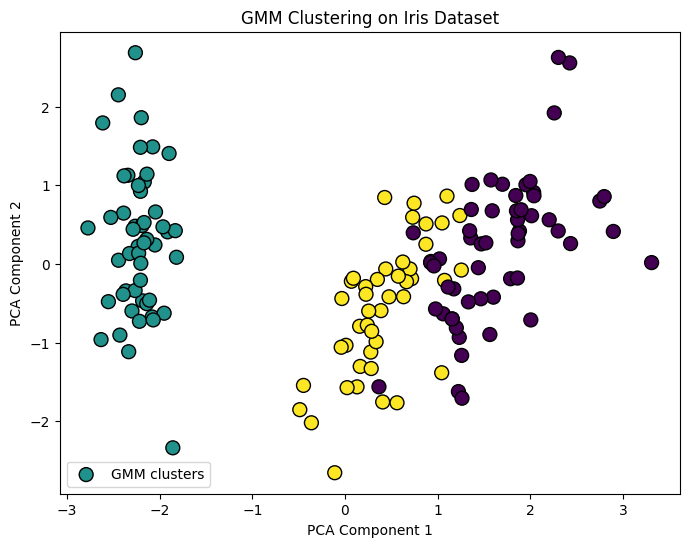

In [6]:

# Plot the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', marker='o', edgecolor='k', s=100, label='GMM clusters')
plt.title('GMM Clustering on Iris Dataset')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

## Mean and covariances

In [7]:
# GMM model parameters
print("Means:\n", gmm.means_)
print("Covariances:\n", gmm.covariances_)

Means:
 [[ 0.85158495 -0.24859804  0.98047264  1.03665053]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 0.08890219 -0.64297712  0.25393414  0.13018296]]
Covariances:
 [[[0.56868206 0.2572427  0.20829787 0.09724537]
  [0.2572427  0.58500486 0.10979199 0.16903018]
  [0.20829787 0.10979199 0.10536011 0.05462615]
  [0.09724537 0.16903018 0.05462615 0.14724193]]

 [[0.17877068 0.27120389 0.01103828 0.01614737]
  [0.27120389 0.74619275 0.01499926 0.02761055]
  [0.01103828 0.01499926 0.00954905 0.00445008]
  [0.01614737 0.02761055 0.00445008 0.01885974]]

 [[0.40444147 0.26962696 0.12762457 0.08726715]
  [0.26962696 0.49050585 0.11912704 0.13028962]
  [0.12762457 0.11912704 0.06527343 0.0460751 ]
  [0.08726715 0.13028962 0.0460751  0.05592973]]]


In [8]:
from sklearn.metrics import silhouette_score

# Calculate clustering evaluation metrics
silhouette_avg = silhouette_score(X_scaled, labels)
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.3742
